# MP vs Ray 框架一致性对比分析

该 Notebook 用于对比在 `torch.multiprocessing` (MP) 框架与 `Ray` 框架下运行相同算法的结果是否一致。  
主要对比指标：**Accuracy (Top-1)** 和 **Loss**。

In [4]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

# 确保可以导入 utils.py
sys.path.append(os.path.abspath("."))
from utils import ResultLoader

## 1. 配置对比参数

在这里设置你想对比的算法、数据集以及超参数。  
程序会自动从 `results/` (MP) 和 `results_ray/` (Ray) 读取对应的数据。

In [5]:
# ================= 配置区域 =================
ALGO = "proxyfl"           # 算法名称
DATASET = "cifar10"       # 数据集
PARTITION = "dirichlet"   # 分区策略
NUM_CLIENTS = 10          # 客户端数量
ROUNDS = 1000               # 对比的轮数（绘图截断点）

# 共有超参数 (必须与运行命令一致)
COMMON_ARGS = {
    "epochs": 10,
    "batch_size": 64,
    "lr": 0.01,
    "alpha": 0.1,         # 针对 dirichlet
}

# 算法专属参数补充
ALGO_ARGS = {
    "fedproto": {"mu": 0.1},
    "fedprox": {"mu": 0.01},
    "fedrep": {"epochs_head": 5},
    "fedtest": {"mu_test": 0.01},
    "fedpln": {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "fixed_proto": 0, "init_emb": 0, "har": 0},
    "feddpc": {"lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01},
    "fedlsa": {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1},
    "proxyfl": {"mu": 1.0}
}

current_algo_args = ALGO_ARGS.get(ALGO, {})
full_args = {**COMMON_ARGS, **current_algo_args}
# ===========================================

## 2. 加载数据

In [6]:
loader_mp = ResultLoader(base_dir="../results")
loader_ray = ResultLoader(base_dir="../results_ray")

print(f"-> Loading results for {ALGO} on {DATASET}...")

# 加载 MP 结果
res_mp = loader_mp.load(ALGO, DATASET, PARTITION, NUM_CLIENTS, specific_run=0, **full_args)

# 加载 Ray 结果
res_ray = loader_ray.load(ALGO, DATASET, PARTITION, NUM_CLIENTS, specific_run=0, **full_args)

if res_mp and res_ray:
    print("✅ Success: Both MP and Ray results found.")
else:
    if not res_mp: print("❌ Error: MP results (results/) not found.")
    if not res_ray: print("❌ Error: Ray results (results_ray/) not found.")

-> Loading results for proxyfl on cifar10...
✅ Success: Both MP and Ray results found.


## 3. 结果对比与可视化

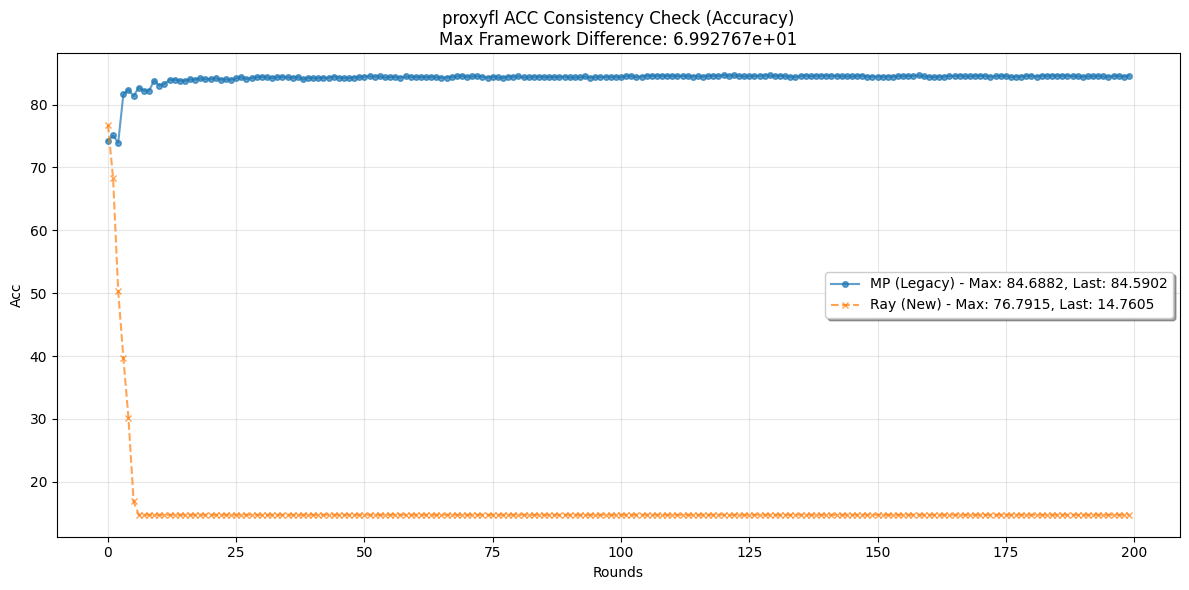

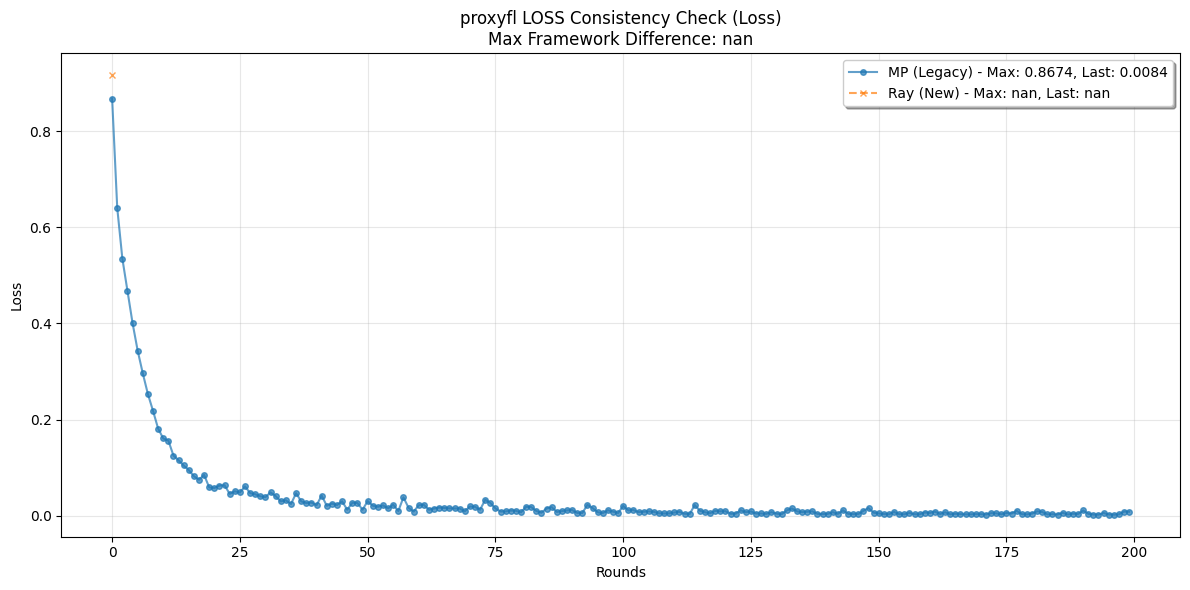

In [7]:
def compare_plots(res_mp, res_ray, metric="acc", title_suffix=""):
    plt.figure(figsize=(12, 6))

    def get_y(data, m):
        val = data.get(m)
        if isinstance(val, dict):
            # 优先取 model 或 local
            k = "model" if "model" in val else "local" if "local" in val else list(val.keys())[0]
            return val[k]
        return val

    y_mp, y_ray = None, None
    if res_mp:
        y_mp = get_y(res_mp, metric)[:ROUNDS]
        max_mp, last_mp = np.max(y_mp), y_mp[-1]
        plt.plot(y_mp, label=f"MP (Legacy) - Max: {max_mp:.4f}, Last: {last_mp:.4f}", marker='o', markersize=4, alpha=0.7)

    if res_ray:
        y_ray = get_y(res_ray, metric)[:ROUNDS]
        max_ray, last_ray = np.max(y_ray), y_ray[-1]
        plt.plot(y_ray, label=f"Ray (New) - Max: {max_ray:.4f}, Last: {last_ray:.4f}", marker='x', markersize=4, linestyle='--', alpha=0.7)

    # 计算最大差异 (仅当两者都存在时)
    if res_mp and res_ray:
        diff = np.abs(np.array(y_mp) - np.array(y_ray))
        max_diff = np.max(diff)
        plt.title(f"{ALGO} {metric.upper()} Consistency Check {title_suffix}\nMax Framework Difference: {max_diff:.6e}")
    else:
        plt.title(f"{ALGO} {metric.upper()} Visualization {title_suffix}")

    plt.xlabel("Rounds")
    plt.ylabel(metric.capitalize())
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if res_mp or res_ray:
    compare_plots(res_mp, res_ray, metric="acc", title_suffix="(Accuracy)")
    compare_plots(res_mp, res_ray, metric="loss", title_suffix="(Loss)")